In [1]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SUBDIVISION  4188 non-null   object 
 1   YEAR         4188 non-null   int64  
 2   JAN          4184 non-null   float64
 3   FEB          4185 non-null   float64
 4   MAR          4182 non-null   float64
 5   APR          4184 non-null   float64
 6   MAY          4185 non-null   float64
 7   JUN          4183 non-null   float64
 8   JUL          4181 non-null   float64
 9   AUG          4184 non-null   float64
 10  SEP          4182 non-null   float64
 11  OCT          4181 non-null   float64
 12  NOV          4177 non-null   float64
 13  DEC          4178 non-null   float64
 14  ANNUAL       4162 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 490.9+ KB
None
                 SUBDIVISION  YEAR   JAN    FEB   MAR    APR    MAY    JUN  \
0  Andam

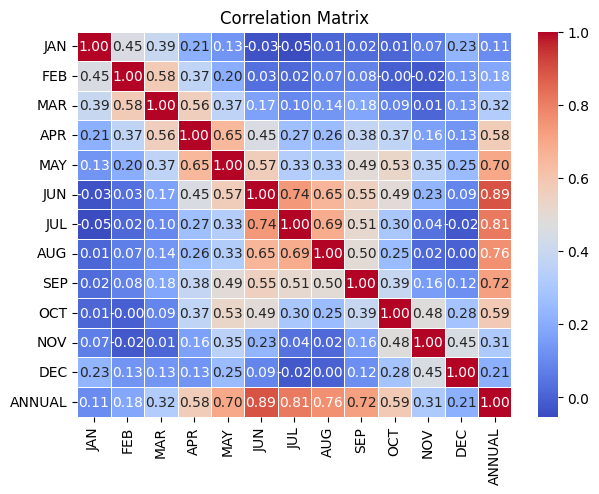

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file into a DataFrame
file_path = "/content/drive/MyDrive/MSC OJT 1/Sub_Division_IMD_2017.csv"
df = pd.read_csv(file_path)

# Display basic information about the DataFrame
print("DataFrame Information:")
print(df.info())

# Display the first few rows of the dataset
print(df.head())

# Summary statistics
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Visualize data distribution
print(df.columns)

df.drop(['YEAR'], axis=1, inplace = True)

# Display correlation matrix
numeric_cols = df.select_dtypes(include='number')
correlation_matrix = numeric_cols.corr()

#correlation_matrix = df.corr()

# Plot a heatmap of the correlation matrix using seaborn
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/MSC OJT 1/Sub_Division_IMD_2017.csv")
df.head(5)

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL
0,Andaman & Nicobar Islands,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2
1,Andaman & Nicobar Islands,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7
2,Andaman & Nicobar Islands,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4
3,Andaman & Nicobar Islands,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6
4,Andaman & Nicobar Islands,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load the CSV file
file_path = '/content/drive/MyDrive/MSC OJT 1/Sub_Division_IMD_2017.csv'
df = pd.read_csv(file_path)

# Assuming 'ANNUAL' is the target variable
target_variable = 'ANNUAL'

# Drop rows with missing values in the target column
df.dropna(subset=[target_variable], inplace=True)

# Features
features = df.drop(columns=[target_variable])

# Identify categorical columns
categorical_cols = [col for col in features.columns if features[col].dtype == 'object']

# Preprocess categorical variables using OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols)
    ],
    remainder='passthrough'
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, df[target_variable], test_size=0.2, random_state=42)

# Fit and transform the data using the preprocessor
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# XGBoost Regressor
model_xgboost = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
model_xgboost.fit(X_train, y_train)

# Predictions
predictions_xgboost = model_xgboost.predict(X_test)

# Evaluate the model
mse_xgboost = mean_squared_error(y_test, predictions_xgboost)
r2_xgboost = r2_score(y_test, predictions_xgboost)

print(f'XGBoost Regression - Mean Squared Error: {mse_xgboost}')
print(f'XGBoost Regression - R-squared: {r2_xgboost}')

XGBoost Regression - Mean Squared Error: 15563.262595093967
XGBoost Regression - R-squared: 0.9818834500879775


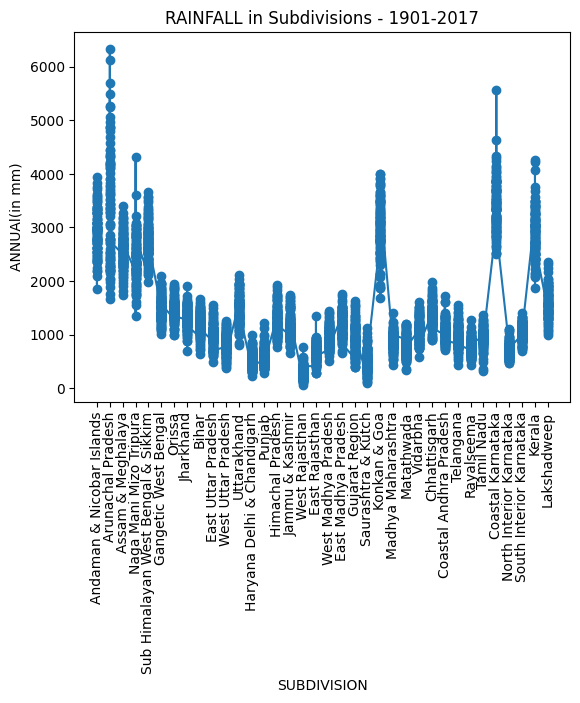

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file into a DataFrame
csv_file_path = "/content/drive/MyDrive/MSC OJT 1/Sub_Division_IMD_2017.csv"
df = pd.read_csv(csv_file_path)

# Assuming your CSV has columns like 'Subdivision' and 'Rainfall' (adjust column names accordingly)
# Replace 'Subdivision' and 'Rainfall' with the actual column names in your CSV
plt.plot(df['SUBDIVISION'], df['ANNUAL'], marker='o', linestyle='-')
plt.xlabel('SUBDIVISION')
plt.ylabel('ANNUAl(in mm)')
plt.title('RAINFALL in Subdivisions - 1901-2017')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
# Show the plot
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the CSV file
file_path = '/content/drive/MyDrive/MSC OJT 1/Sub_Division_IMD_2017.csv'
df = pd.read_csv(file_path)

# Assuming 'ANNUAL' is the target variable
target_variable = 'ANNUAL'

# Drop rows with missing values in the target column
df.dropna(subset=[target_variable], inplace=True)

# Features
features = df.drop(columns=[target_variable])

# Identify categorical columns
categorical_cols = [col for col in features.columns if features[col].dtype == 'object']

# Separate numerical and categorical features
numerical_cols = features.columns.difference(categorical_cols)

# Preprocess numerical features using StandardScaler
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, df[target_variable], test_size=0.2, random_state=42)

# Preprocess the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Create and train the Multiple Linear Regression model
model_multiple_linear_regression = LinearRegression()
model_multiple_linear_regression.fit(X_train_processed, y_train)

# Predictions
predictions_multiple_linear_regression = model_multiple_linear_regression.predict(X_test_processed)

# Evaluate the model
mse_multiple_linear_regression = mean_squared_error(y_test, predictions_multiple_linear_regression)
r2_multiple_linear_regression = r2_score(y_test, predictions_multiple_linear_regression)

print(f'Multiple Linear Regression - Mean Squared Error: {mse_multiple_linear_regression}')
print(f'Multiple Linear Regression - R-squared: {r2_multiple_linear_regression}')


Multiple Linear Regression - Mean Squared Error: 0.009439836007263155
Multiple Linear Regression - R-squared: 0.9999999890114776


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load the CSV file
file_path = '/content/drive/MyDrive/MSC OJT 1/Sub_Division_IMD_2017.csv'
df = pd.read_csv(file_path)

# Assuming 'ANNUAL' is the target variable
target_variable = 'ANNUAL'

# Drop rows with missing values in the target column
df.dropna(subset=[target_variable], inplace=True)

# Features
features = df.drop(columns=[target_variable])

# Identify categorical columns
categorical_cols = [col for col in features.columns if features[col].dtype == 'object']

# Separate numerical and categorical features
numerical_cols = features.columns.difference(categorical_cols)

# Preprocess categorical variables using OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, df[target_variable], test_size=0.2, random_state=42)

# Preprocess the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Random Forest Regressor
model_random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
model_random_forest.fit(X_train_processed, y_train)

# Predictions
predictions_random_forest = model_random_forest.predict(X_test_processed)

# Evaluate the model
mse_random_forest = mean_squared_error(y_test, predictions_random_forest)
r2_random_forest = r2_score(y_test, predictions_random_forest)
print(f'Random Forest Regression - Mean Squared Error: {mse_random_forest}')
print(f'Random Forest Regression - R-squared: {r2_random_forest}')


Random Forest Regression - Mean Squared Error: 22628.039669935155
Random Forest Regression - R-squared: 0.9736596354660988


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the CSV file
file_path = '/content/drive/MyDrive/MSC OJT 1/Sub_Division_IMD_2017.csv'
df = pd.read_csv(file_path)

# Assuming 'ANNUAL' is the target variable
target_variable = 'ANNUAL'

# Drop rows with missing values in the target column
df.dropna(subset=[target_variable], inplace=True)

# Features
features = df.drop(columns=[target_variable])

# Identify categorical columns
categorical_cols = [col for col in features.columns if features[col].dtype == 'object']
numerical_cols = features.columns.difference(categorical_cols)

# Preprocess features using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, df[target_variable], test_size=0.2, random_state=42)

# Create the Lasso Regression model pipeline
model_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1.0))  # You can adjust the alpha parameter
])

# Train the model
model_lasso.fit(X_train, y_train)

# Predictions
predictions_lasso = model_lasso.predict(X_test)

# Evaluate the model
mse_lasso = mean_squared_error(y_test, predictions_lasso)
r2_lasso = r2_score(y_test, predictions_lasso)

print(f'Lasso Regression - Mean Squared Error: {mse_lasso}')
print(f'Lasso Regression - R-squared: {r2_lasso}')


Lasso Regression - Mean Squared Error: 4.393554202735096
Lasso Regression - R-squared: 0.9999948856453769
